# Imports

In [85]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from ppmi_utils import (
    cohort_map,
    event_id_to_visit,
    fields,
    load_ppmi_csvs,
    merge_ppmi_tables,
    numeric_fields,
    parse_imaging_protocol,
    plot_bar,
    plot_hist,
    primdiag_map,
    visit_to_event_id,
)

ROOT_DIR = Path(os.getcwd()).resolve().parents[1]
PPMI_CLINICAL = ROOT_DIR / "csv_dir" / "PPMI_CLINICAL"
PPMI_OTHERS = ROOT_DIR / "csv_dir" / "PPMI_OTHERS"
curated_data = PPMI_OTHERS / "PPMI_Curated_Data_Cut_Public_20251112.xlsx"
ppmi_imaging_descriptions_path = "/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_imaging_descriptions.json"
ppmi_imaging_ignored_path = "/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_imaging_ignored.csv"

# CSV preprocessing

### Uncurated clinical tabular data 

Not cureated, so might not be used unless missing info in the curated data need to be found here

In [86]:
ppmi_data = load_ppmi_csvs(PPMI_CLINICAL)
print(f"Available dataframes: {list(ppmi_data.keys())}")

Available dataframes: ['Participant_Status', 'MDS-UPDRS_Part_IV__Motor_Complications', 'Primary_Clinical_Diagnosis', 'MDS-UPDRS_Part_I', 'Symbol_Digit_Modalities_Test', 'MDS-UPDRS_Part_III', 'Montreal_Cognitive_Assessment__MoCA_', 'Clock_Drawing', 'Socio-Economics', 'Modified_Semantic_Fluency', 'Demographics', 'Modified_Boston_Naming_Test', 'MDS_UPDRS_Part_II__Patient_Questionnaire', 'Benton_Judgement_of_Line_Orientation', 'Clinical_Diagnosis', 'Letter_-_Number_Sequencing', 'Age_at_visit', 'MDS-UPDRS_Part_I_Patient_Questionnaire', 'University_of_Pennsylvania_Smell_Identification_Test_UPSIT']


In [87]:
uncurated_clinical_df = merge_ppmi_tables(ppmi_data)
print("Uncurated DataFrame shape:", uncurated_clinical_df.shape)
print("Uncurated DataFrame columns:", uncurated_clinical_df.columns.tolist())

Uncurated DataFrame shape: (54734, 461)
Uncurated DataFrame columns: ['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'NP4WDYSK', 'NP4WDYSKDEN', 'NP4WDYSKNUM', 'NP4WDYSKPCT', 'NP4DYSKI', 'NP4OFF', 'NP4OFFDEN', 'NP4OFFNUM', 'NP4OFFPCT', 'NP4FLCTI', 'NP4FLCTX', 'NP4DYSTN', 'NP4DYSTNDEN', 'NP4DYSTNNUM', 'NP4DYSTNPCT', 'NP4TOT', 'ORIG_ENTRY', 'LAST_UPDATE', 'REC_ID_Primary_Clinical_Diagnosis', 'PAG_NAME_Primary_Clinical_Diagnosis', 'INFODT_Primary_Clinical_Diagnosis', 'PRIMDIAG', 'NEWDIAGEXP', 'OTHNEURO', 'DXLVL', 'ORIG_ENTRY_Primary_Clinical_Diagnosis', 'LAST_UPDATE_Primary_Clinical_Diagnosis', 'REC_ID_MDS-UPDRS_Part_I', 'PAG_NAME_MDS-UPDRS_Part_I', 'INFODT_MDS-UPDRS_Part_I', 'NUPSOURC', 'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1RTOT', 'ORIG_ENTRY_MDS-UPDRS_Part_I', 'LAST_UPDATE_MDS-UPDRS_Part_I', 'REC_ID_Symbol_Digit_Modalities_Test', 'PAG_NAME_Symbol_Digit_Modalities_Test', 'INFODT_Symbol_Digit_Modalities_Test', 'SDMTOTAL', 'SDMTVRSN', 'AGE_ASSESS_SDM', 'D

### Official curated merge tabular data

In [88]:
curated_clinical_df = pd.read_excel(curated_data)
print("Curated Clinical DataFrame shape:", curated_clinical_df.shape)
print("Curated Clinical DataFrame columns:", curated_clinical_df.columns.tolist())

Curated Clinical DataFrame shape: (17252, 179)
Curated Clinical DataFrame columns: ['SITE', 'PATNO', 'COHORT', 'subgroup', 'enroll_phase', 'enroll_source', 'analytic_subgroup', 'HIQ_RBD', 'study_status', 'NSD_Status', 'NSD_STAGE', 'PRIMDIAG', 'OTHNEURO', 'EVENT_ID', 'YEAR', 'visit_date', 'age', 'age_at_visit', 'SEX', 'EDUCYRS', 'race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE', 'fampd', 'fampd_bin', 'handed', 'howlive', 'sex_orient', 'BMI', 'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE', 'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other', 'sym_unknown', 'PDTRTMNT', 'LEDD', 'age_datscan', 'age_LP', 'age_upsit', 'upsit', 'upsit_pctl', 'upsit_pctl15', 'moca', 'bjlot', 'DVS_JLO_MSSA', 'DVS_JLO_MSSAE', 'clockdraw', 'DVT_CLCKDRAW', 'DVZ_CLCKDRAW', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'HVLTFPRL', 'HVLTRDLY', 'HVLTREC', 'DVT_TOTAL_RECALL', 'DVT_DELAYED_RECALL', 'DVT_RETENTION', 'DVT_RECOG_DISC_INDEX', 'lexical', 'DVT_FAS', 'DVS_FAS', 'l

### idaSearch (image info)

In [89]:
# ida search csv load and preprocessing
ida_df = pd.read_csv(PPMI_OTHERS / "idaSearch_18Feb2026.csv", low_memory=False)
ida_df = ida_df[~ida_df["Modality"].isin(["Path", "CT"])].copy()
ida_df["Weight"] = ida_df["Weight"].replace(0, np.nan)
ida_df["Age"] = ida_df["Age"].replace(0, np.nan)
ida_df["Study Date"] = pd.to_datetime(ida_df["Study Date"], errors="coerce")
ida_df = ida_df.rename(columns={"Subject ID": "PATNO"})
protocol_parsed = ida_df["Imaging Protocol"].apply(parse_imaging_protocol)
for field in fields:
    ida_df[field] = protocol_parsed.apply(lambda x: x.get(field, np.nan))
for field in numeric_fields:
    ida_df[field] = pd.to_numeric(ida_df[field], errors="coerce")


print("ida searchDataFrame shape:", ida_df.shape)
print(ida_df.columns.tolist())

ida searchDataFrame shape: (81436, 28)
['PATNO', 'Project', 'Sex', 'Weight', 'Research Group', 'Visit', 'Study Date', 'Archive Date', 'Age', 'GDSCALE Total Score', 'Modality', 'Description', 'Type', 'Imaging Protocol', 'Image ID', 'Structure', 'Laterality', 'Image Type', 'Registration', 'Tissue', 'Acquisition Plane', 'Slice Thickness', 'Matrix Z', 'Acquisition Type', 'Manufacturer', 'Mfg Model', 'Field Strength', 'Weighting']


# Advanced modalities 

### setup

In [90]:
# avanced modalities
with open(ppmi_imaging_descriptions_path, "r") as f:
    modality_dict = json.load(f)


def normalize_list(lst):
    return [s.strip().upper() for s in lst]


dwi_set = set(normalize_list(modality_dict["dwi"]))
func_set = set(normalize_list(modality_dict["func"]))
anat_sets = {k: set(normalize_list(v)) for k, v in modality_dict["anat"].items()}
ignore_df = pd.read_csv(ppmi_imaging_ignored_path)
ignore_set = set(ignore_df["Description"].str.strip().str.upper())
ida_df["Description_clean"] = ida_df["Description"].astype(str).str.strip().str.upper()
ida_df = ida_df[~ida_df["Description_clean"].isin(ignore_set)].copy()

In [91]:
def classify_advanced(row):
    desc = row["Description_clean"]
    modality = row["Modality"]
    # --- DWI ---
    if desc in dwi_set:
        return "DWI"
    # --- Functional ---
    if desc in func_set:
        return "rsfMRI"
    # --- Anatomical ---
    for anat_type, anat_set in anat_sets.items():
        if desc in anat_set:
            return anat_type  # T1w, T2w, T2starw, FLAIR
    # --- Nuclear imaging ---
    if modality == "PET":
        return "PET"
    if modality == "SPECT":
        return "SPECT"
    # --- fallback ---
    if modality == "MRI":
        return "MRI_other"
    if modality == "DTI":
        return "DTI_other"
    if modality == "fMRI":
        return "fMRI_other"
    return "Unknown"


ida_df["Advanced_Modality"] = ida_df.apply(classify_advanced, axis=1)

# print(ida_df["Advanced_Modality"].value_counts())
# print(pd.crosstab(ida_df["Modality"], ida_df["Advanced_Modality"]))

### Merge clinical and imaging info

In [92]:
# merge clinical and imaging dataframes
ida_df["PATNO"] = ida_df["PATNO"].astype(str)
curated_clinical_df["PATNO"] = curated_clinical_df["PATNO"].astype(str)
ida_df["EVENT_ID"] = ida_df["Visit"].map(visit_to_event_id)
curated_clinical_df["PRIMDIAG_DESC"] = curated_clinical_df["PRIMDIAG"].map(primdiag_map)
curated_clinical_df["COHORT_DESC"] = curated_clinical_df["COHORT"].map(cohort_map)

cohort_map
df = pd.merge(
    curated_clinical_df,
    ida_df,
    # how="left",
    how="outer",
    on=["PATNO", "EVENT_ID"],
    suffixes=("", "_idasearch"),  # Curated stays same, Imaging gets '_ida' suffix
)
df["Visit"] = df["EVENT_ID"].map(event_id_to_visit)

print("Final merged DataFrame shape:", df.shape)
print("Final merged DataFrame columns:", df.columns.tolist())

Final merged DataFrame shape: (91617, 210)
Final merged DataFrame columns: ['SITE', 'PATNO', 'COHORT', 'subgroup', 'enroll_phase', 'enroll_source', 'analytic_subgroup', 'HIQ_RBD', 'study_status', 'NSD_Status', 'NSD_STAGE', 'PRIMDIAG', 'OTHNEURO', 'EVENT_ID', 'YEAR', 'visit_date', 'age', 'age_at_visit', 'SEX', 'EDUCYRS', 'race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE', 'fampd', 'fampd_bin', 'handed', 'howlive', 'sex_orient', 'BMI', 'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE', 'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other', 'sym_unknown', 'PDTRTMNT', 'LEDD', 'age_datscan', 'age_LP', 'age_upsit', 'upsit', 'upsit_pctl', 'upsit_pctl15', 'moca', 'bjlot', 'DVS_JLO_MSSA', 'DVS_JLO_MSSAE', 'clockdraw', 'DVT_CLCKDRAW', 'DVZ_CLCKDRAW', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'HVLTFPRL', 'HVLTRDLY', 'HVLTREC', 'DVT_TOTAL_RECALL', 'DVT_DELAYED_RECALL', 'DVT_RETENTION', 'DVT_RECOG_DISC_INDEX', 'lexical', 'DVT_FAS', 'DVS_FAS', 'lns', 'DV

/tmp/ipykernel_9452/1893907810.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  curated_clinical_df["PRIMDIAG_DESC"] = curated_clinical_df["PRIMDIAG"].map(primdiag_map)
/tmp/ipykernel_9452/1893907810.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  curated_clinical_df["COHORT_DESC"] = curated_clinical_df["COHORT"].map(cohort_map)


In [93]:
# patient_ex = df[(df["PATNO"] == "100445") & (df["EVENT_ID"] == "BL")].copy()
# print(patient_ex.shape)
# patient_ex.to_csv("patient_ex.csv", index=False)

# Filters

General filters

In [94]:
# general filters
print("Before filter:")
print("Shape ", df.shape)
print("unique patient ", df["PATNO"].nunique())
print("unique patient-visit pairs ", df.groupby(["PATNO", "EVENT_ID"]).ngroups)

df.groupby(["PATNO", "EVENT_ID"]).ngroups
df = df[df["EVENT_ID"].notna()].copy()  # only keep rows with valid event_id
df = df[df["Research Group"] != "Phantom"].copy()  # remove phantom scans
df = df[df["Image ID"].notna()].copy()  # only keep rows with imaging data

# # FILTERS IN on images

df = df[
    # (df["Advanced_Modality"].isin(["DWI"]))
    ~(df["Advanced_Modality"].isin(["MRI_other", "DTI_other", "fMRI_other", "Unknown"]))
    # & (df["Advanced_Modality"].isin(["PET"]))
].copy()

# # FILTER OUT on images
df = df[
    (
        (df["Advanced_Modality"] != "T1w")
        | ((df["Acquisition Type"] == "3D") | (df["Matrix Z"] >= 70))
    )
].copy()

df = df[
    (
        (df["Advanced_Modality"] != "T2w")
        | ((df["Acquisition Type"] == "3D") | (df["Matrix Z"] >= 70))
    )
].copy()

df = df[
    (
        (df["Advanced_Modality"] != "FLAIR")
        | ((df["Acquisition Type"] == "3D") | (df["Matrix Z"] >= 70))
    )
].copy()

df = df[
    (df["Advanced_Modality"] != "DWI")
    | (df["Description"].str.lower().str.contains("DTI_revb0_AP".lower()))
].copy()


Before filter:
Shape  (91617, 210)
unique patient  5696
unique patient-visit pairs  20551


In [95]:
print(df["Description"].unique().tolist())

# Get the list
desc_list = df["Description"].unique().tolist()

# Save to a txt file
with open("descriptions.txt", "w", encoding="utf-8") as f:
    for item in desc_list:
        f.write(str(item) + "\n")

['SAG 3D MPRAGE', 'RESTING STATE FMRI ep2d_fid_basic_bold', '3D T2 FLAIR', '3D T2 FLAIR_ND', 'EM', 'TX', 'DaT Brain Tomo', 'Reconstructed DaTSCAN <- DaT Brain Tomo', 'AV 133 Delay 4i/16s-filtered', 'TX Scan 4min 4i/16s', 'AV 133 Delay 4i/16s-unfiltered', 'AV 133 Delay 4i/16s-UNFILTERED', 'AV 133 Delay 4i/16s-FILTERED', 'AV 133 Delay 4i/16s - FILTERED', 'AV 133 Delay 4i/16s - UNFILTERED', 'L>R RESTING STATE FMRI ep2d_fid_basic_bold', 'R>L RESTING STATE FMRI ep2d_fid_basic_bold', '3D T2 SAG FLAIR', '3D T2 SAG FLAIR_ND', 'Sag 3D T2 FLAIR', 'SAG 3D T1 FSPGR', 'rsFMRI ep2d', 'rsFMRI ep2dREPEAT', 'I123 DaTScan', 'Reconstructed DaTSCAN', 'DaTscan', 'Reconstructed DaTSCAN <- DaTscan', 'Brain Tomo', 'Reconstructed DaTSCAN <- Brain Tomo', 'Reconstructed DaTSCAN <- PPMI 2.0', '3D T1 _weighted', '2D GRE-MT', 'rsfMRI_RL', 'rsfMRI_L_R', 'ep2d_bold_rest', 'rsfMRI_PA', 'rsfMRI_AP', 'Symbia PPMI 2.0', 'DTI_revB0_AP', '3D T1-weighted', 'rsfMRI_LR', 'Invicro Brain SPECT', 'Reconstructed DaTSCAN <- Invicr

In [96]:
print("After filter:")
print("Shape ", df.shape)
print("unique patient ", df["PATNO"].nunique())
print("unique patient-visit pairs ", df.groupby(["PATNO", "EVENT_ID"]).ngroups)

After filter:
Shape  (40021, 210)
unique patient  3816
unique patient-visit pairs  8442


### Filter VISIT or PATIENTS based on required image modalities

possible values are

DWI, rsfMRI, T1w, T2w, T2starw, FLAIR, PET, SPECT

MRI_other
fMRI_other
DTI_other
Unknown


In [ ]:
# Choose filtering mode
strict_per_visit = (
    True  # True = must have all modalities in a single visit, False = across all visits
)

# Define required modalities
required_modalities = {"T1w", "DWI", "MT"}
required_modalities = {"T1w", "DWI"}
required_modalities = {"T1w", "MT"}
required_modalities = {"DWI", "MT"}
# required_modalities = {"T1w", "FLAIR", "DWI", "MT", "rsfMRI"}
# required_modalities = {"T1w", "MT"}
# required_modalities = {"T1w", "FLAIR"}

if strict_per_visit:
    # ----------------------------
    # Strict: visit must have all modalities
    # ----------------------------
    visit_modalities = (
        df.groupby(["PATNO", "EVENT_ID"])["Advanced_Modality"].unique().reset_index()
    )
    visit_modalities["has_all"] = visit_modalities["Advanced_Modality"].apply(
        lambda mods: required_modalities.issubset(set(mods))
    )
    valid_visits = visit_modalities.loc[
        visit_modalities["has_all"], ["PATNO", "EVENT_ID"]
    ]
    df_filtered = df.merge(valid_visits, on=["PATNO", "EVENT_ID"], how="inner")

else:
    # ----------------------------
    # Less strict: patient must have all modalities across all visits
    # ----------------------------
    patient_modalities = (
        df.groupby("PATNO")["Advanced_Modality"]
        .apply(lambda mods: set(mods))
        .reset_index()
    )
    patient_modalities["has_all"] = patient_modalities["Advanced_Modality"].apply(
        lambda mods: required_modalities.issubset(mods)
    )
    valid_patients = patient_modalities.loc[patient_modalities["has_all"], "PATNO"]
    df_filtered = df[df["PATNO"].isin(valid_patients)].copy()

print(f"Original rows: {len(df)}, filtered rows: {len(df_filtered)}")
print("unique patients:", df_filtered["PATNO"].nunique())
print("unique patient-visit pairs:", df_filtered.groupby(["PATNO", "EVENT_ID"]).ngroups)

# Update df
df = df_filtered.copy()

Original rows: 40021, filtered rows: 23569
unique patients: 1455
unique patient-visit pairs: 2179


In [98]:
# print percetage of na values in each column in the following list
col_list = ["PRIMDIAG", "COHORT", "Research Group", "subgroup", "Image ID"]
for col in col_list:
    na_percentage = df[col].isna().mean() * 100
    print(f"{col}: {na_percentage:.2f}% NA values")

PRIMDIAG: 1.64% NA values
COHORT: 1.45% NA values
Research Group: 0.00% NA values
subgroup: 1.45% NA values
Image ID: 0.00% NA values


# Basic analysis

### Patients and visits without images

In [99]:
# Visits without image ID
df_no_image_id = df[df["Image ID"].isna()]
n_visits_no_image = df_no_image_id.groupby(["PATNO", "EVENT_ID"]).ngroups
print(f"Number of visits without 'Image ID': {n_visits_no_image}")

total_visits = df.groupby(["PATNO", "EVENT_ID"]).ngroups
print(f"Total number of visits: {total_visits}")
print(
    f"Percentage of visits without 'Image ID': {n_visits_no_image / total_visits:.2%}"
)

Number of visits without 'Image ID': 0
Total number of visits: 2179
Percentage of visits without 'Image ID': 0.00%


In [100]:
# Number of unique patients with at least one visit without image ID
# Total number of patients
total_patients = df["PATNO"].nunique()
# Number of patients with no images at all
patients_with_image = df.loc[df["Image ID"].notna(), "PATNO"].unique()
patients_no_image = set(df["PATNO"]) - set(patients_with_image)
n_patients_no_image = len(patients_no_image)

print(f"Total patients: {total_patients}")
print(f"Patients with no image at all: {n_patients_no_image}")
print(f"Percentage with no image: {n_patients_no_image / total_patients:.2%}")


Total patients: 1455
Patients with no image at all: 0
Percentage with no image: 0.00%


### Age at baseline

Baseline age summary (one row per patient):
      count      mean       std        min        25%        50%        75%  \
age  1292.0  66.33097  8.158663  30.410959  62.258904  66.960274  71.449315   

           max  
age  87.394521  


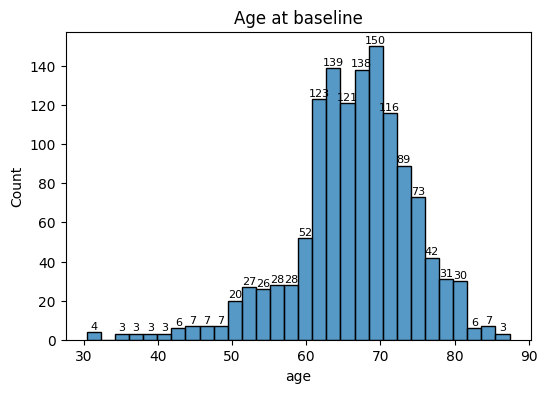

In [101]:
baseline_df = df[df["EVENT_ID"] == "BL"].copy()
baseline_unique = baseline_df.drop_duplicates(subset=["PATNO"])  # keep first occurence
print("Baseline age summary (one row per patient):")
print(baseline_unique[["age"]].describe().T)
plot_hist(baseline_unique, "age", title="Age at baseline")

### Sex distribution

Sex distribution per patient:
Sex
M    815
F    640
Name: count, dtype: int64
Sex distribution at baseline:
Sex      M    F
count  815  640


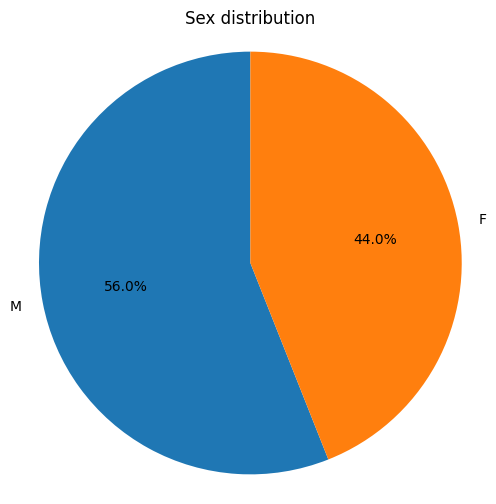

In [102]:
# Count occurrences
# Get most frequent Sex per patient
sex_per_patient = df.groupby("PATNO")["Sex"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)

# Count distribution
sex_counts = sex_per_patient.value_counts(dropna=False)

print("Sex distribution per patient:")
print(sex_counts)

# Print table
print("Sex distribution at baseline:")
print(sex_counts.to_frame().T)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct="%1.1f%%",  # show percentage
    startangle=90,  # rotate to start from top
)
plt.title("Sex distribution")
plt.axis("equal")  # equal aspect ratio ensures pie is circular
plt.show()


### Cohort definition
1. Parkinson’s Disease, i.e., people who have a formal diagnosis of Parkinson’s disease (PD) 
2. Prodromal, i.e., people who are at risk of developing PD based on clinical features, genetic variants or other biomarkers but have not been formally diagnosed 
3. Healthy Controls, i.e., people with no neurologic disorder and no first-degree relative with PD
4. SWEDD (Scan without dopaminergic deficit). This is a small legacy cohort that you may wish to exclude, depending on your research purpose; for more details, see https://www.ppmi-info.org/study-design/study-cohorts#legacy/

Diagnosis distribution at baseline:


/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_utils.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette="viridis")


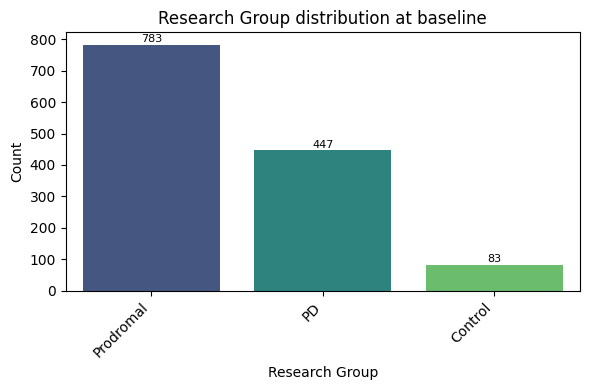

In [103]:
# diagnosis at baseline
print("Diagnosis distribution at baseline:")
cohort_counts = baseline_unique["Research Group"].value_counts(dropna=False)
# print(cohort_counts.to_frame().T)
plot_bar(
    baseline_unique.reset_index(drop=True),
    "Research Group",
    title="Research Group distribution at baseline",
)

/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_utils.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette="viridis")


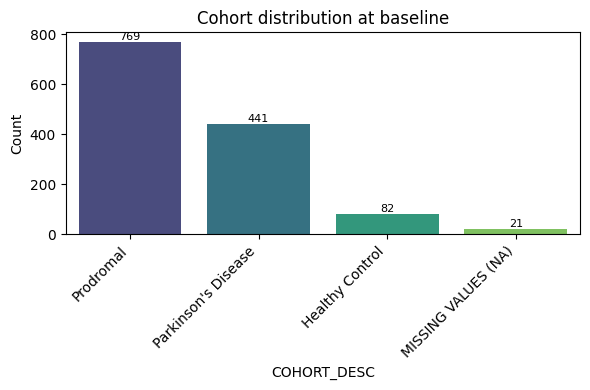

In [104]:
cohort_counts = baseline_unique["COHORT_DESC"].value_counts(dropna=False)
# print(cohort_counts.to_frame().T)
plot_bar(
    baseline_unique.reset_index(drop=True),
    "COHORT_DESC",
    title="Cohort distribution at baseline",
)

### subgroup
Subgroup is derived from various source columns to give a more detailed group assignment than cohort. It can take values of Healthy Control, SWEDD, SWEDD/PD, SWEDD/nonPD, Hyposmia, RBD, Sporadic PD, LRRK2, GBA, PINK1, PRKN, SNCA or combinations of genetic variants and/or RBD (e.g. LRRK2 + GBA, GBA + RBD).

/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_utils.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette="viridis")


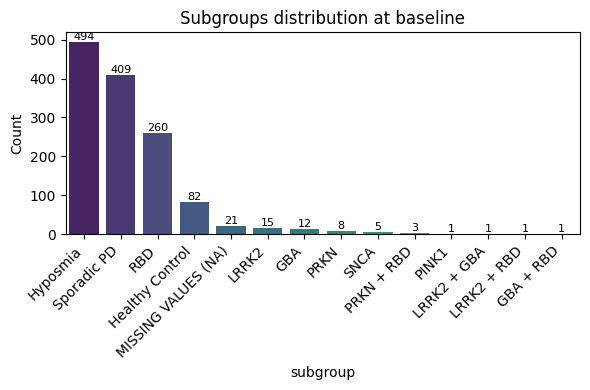

In [105]:
cohort_counts = baseline_unique["subgroup"].value_counts(dropna=False)
# print(cohort_counts.to_frame().T)
plot_bar(
    baseline_unique.reset_index(drop=True),
    "subgroup",
    title="Subgroups distribution at baseline",
)

### PRIMDIAG

/home/falconnier/Documents/mri-preprocessing/csv_exploration/PPMI_explo/ppmi_utils.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts.values, palette="viridis")


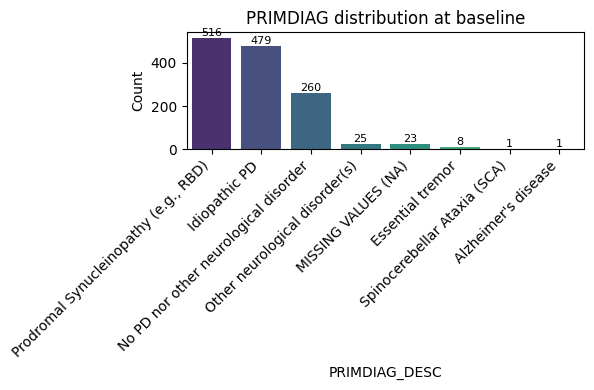

In [106]:
cohort_counts = baseline_unique["PRIMDIAG_DESC"].value_counts(dropna=False)
# print(cohort_counts.to_frame().T)
plot_bar(
    baseline_unique.reset_index(drop=True),
    "PRIMDIAG_DESC",
    title="PRIMDIAG distribution at baseline",
)

### cross tab for diag, subgroup, research group

subgroup                               GBA  GBA + RBD  Healthy Control  \
PRIMDIAG_DESC                                                            
Alzheimer's disease                      0          0                0   
Essential tremor                         0          0                0   
Idiopathic PD                            9          0                0   
No PD nor other neurological disorder    1          0               82   
Other neurological disorder(s)           0          0                0   
Prodromal Synucleinopathy (e.g., RBD)    2          1                0   
Spinocerebellar Ataxia (SCA)             0          0                0   

subgroup                               Hyposmia  LRRK2  LRRK2 + GBA  \
PRIMDIAG_DESC                                                         
Alzheimer's disease                           1      0            0   
Essential tremor                              7      0            0   
Idiopathic PD                                34  

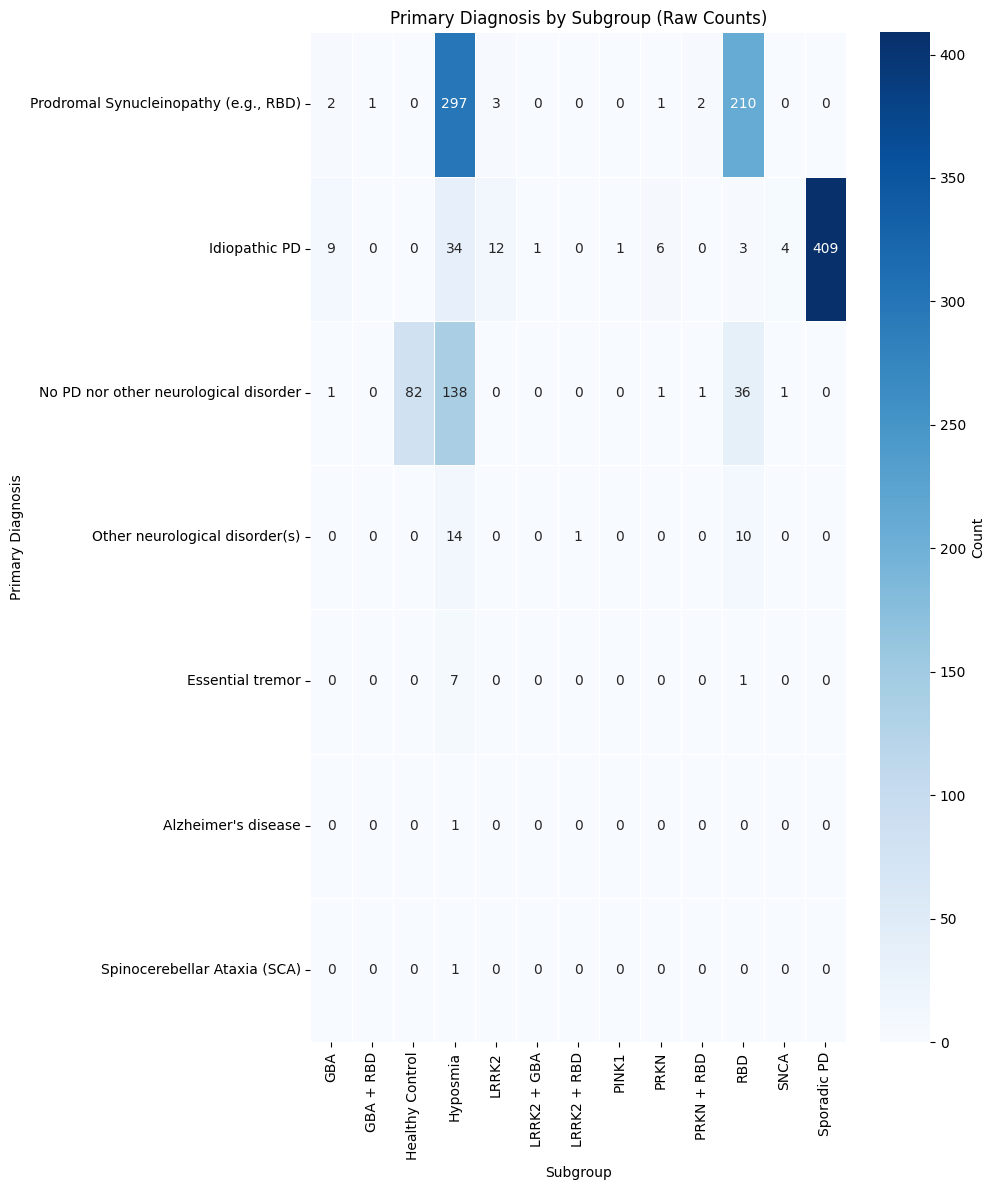

In [107]:
print(pd.crosstab(baseline_unique["PRIMDIAG_DESC"], baseline_unique["subgroup"]))


# Create crosstab
ct = pd.crosstab(
    baseline_unique["PRIMDIAG_DESC"],
    # baseline_unique["Research Group"],
    baseline_unique["subgroup"],
)

# Optional: sort by total frequency
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# Plot heatmap
plt.figure(figsize=(10, 12))

sns.heatmap(
    ct,
    annot=True,  # show raw numbers
    fmt="d",  # integer formatting
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Count"},
)

plt.title("Primary Diagnosis by Subgroup (Raw Counts)")
plt.xlabel("Subgroup")
plt.ylabel("Primary Diagnosis")
plt.tight_layout()
plt.show()

In [108]:
# series1 = baseline_unique["Research Group"]
# series2 = baseline_unique["PRIMDIAG_DESC"]
# # series2 = baseline_unique["subgroup"]
# print(pd.crosstab(series2, series1))

# Longitudinal analysis

### Cumulative number of visits through years

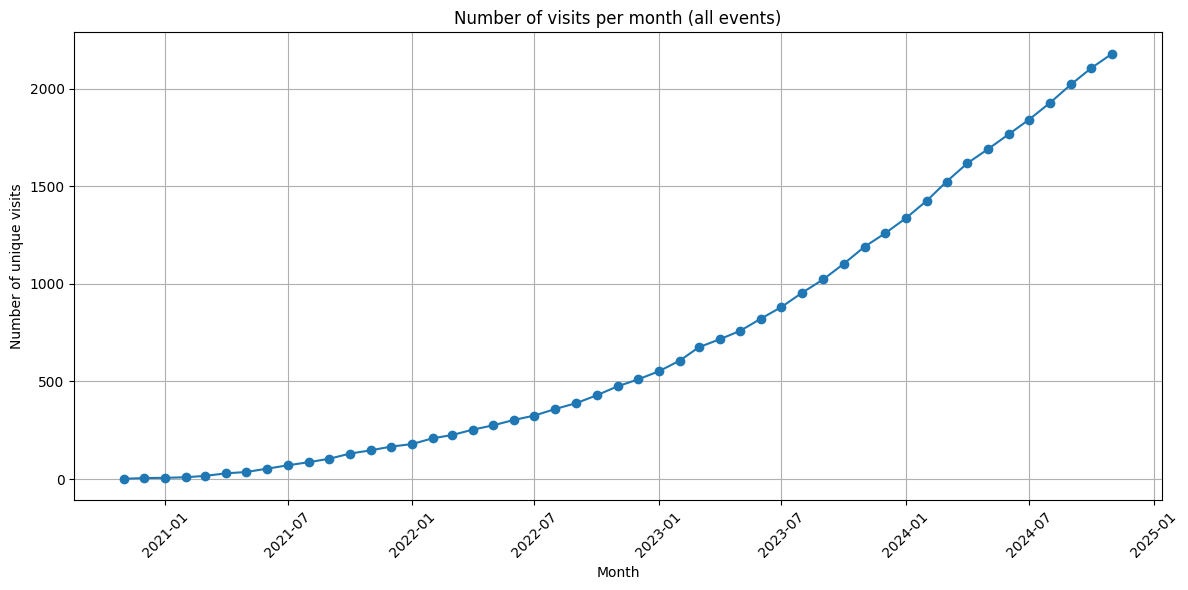

In [109]:
# Ensure Study Date is datetime
df["Study Date"] = pd.to_datetime(df["Study Date"], errors="coerce")

# Keep only unique patient-event pairs
unique_visits = df.drop_duplicates(subset=["PATNO", "EVENT_ID"])
unique_visits = unique_visits[unique_visits["Study Date"] >= "2010-01-01"]
unique_visits["YearMonth"] = unique_visits["Study Date"].dt.to_period("M")
visits_per_month = unique_visits.groupby("YearMonth").size()

visits_per_month = visits_per_month.cumsum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(visits_per_month.index.to_timestamp(), visits_per_month.values, marker="o")
plt.title("Number of visits per month (all events)")
plt.xlabel("Month")
plt.ylabel("Number of unique visits")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### How many visits per patient ?

Visits per patient (summary):
           count      mean       std  min  25%  50%  75%  max
EVENT_ID  1455.0  1.497595  0.689747  1.0  1.0  1.0  2.0  3.0


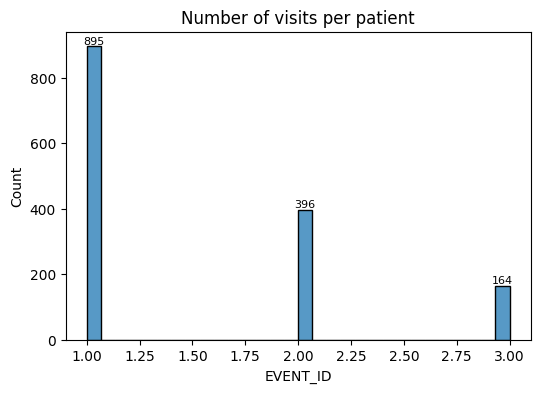

In [110]:
visits_per_patient = df.groupby("PATNO")["EVENT_ID"].nunique()
print("Visits per patient (summary):")
print(visits_per_patient.describe().to_frame().T)
# Histogram of visit counts
plot_hist(
    visits_per_patient.reset_index(), "EVENT_ID", title="Number of visits per patient"
)

### Longitudinal diagnosis changes

There is no change for 
column_name_for_transition = "COHORT_DESC"
column_name_for_transition = "Research Group"

Number of patients with diagnosis change: 82


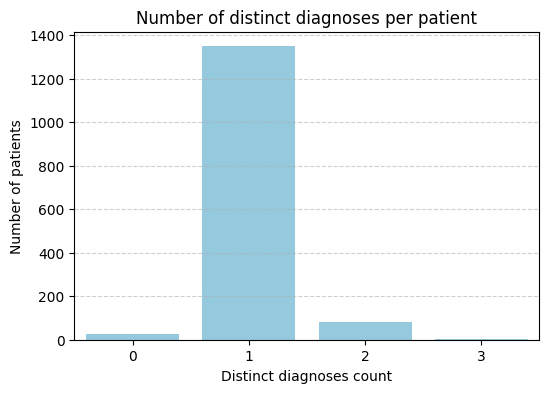

In [111]:
column_name_for_transition = "PRIMDIAG_DESC"

# number of distinct diagnoses per patient
diagnosis_over_time = df.groupby("PATNO")[column_name_for_transition].nunique()

# Patients with >1 diagnosis
patients_changed_diag = diagnosis_over_time[diagnosis_over_time > 1]
print(f"Number of patients with diagnosis change: {len(patients_changed_diag)}")

# diagnosis_per_patient = df.groupby("PATNO")[column_name].unique()
# for pat in patients_changed_diag.index:
#     print(f"{pat}: {diagnosis_per_patient[pat]}")

# Plot distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=diagnosis_over_time, color="skyblue")
plt.title("Number of distinct diagnoses per patient")
plt.xlabel("Distinct diagnoses count")
plt.ylabel("Number of patients")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

85


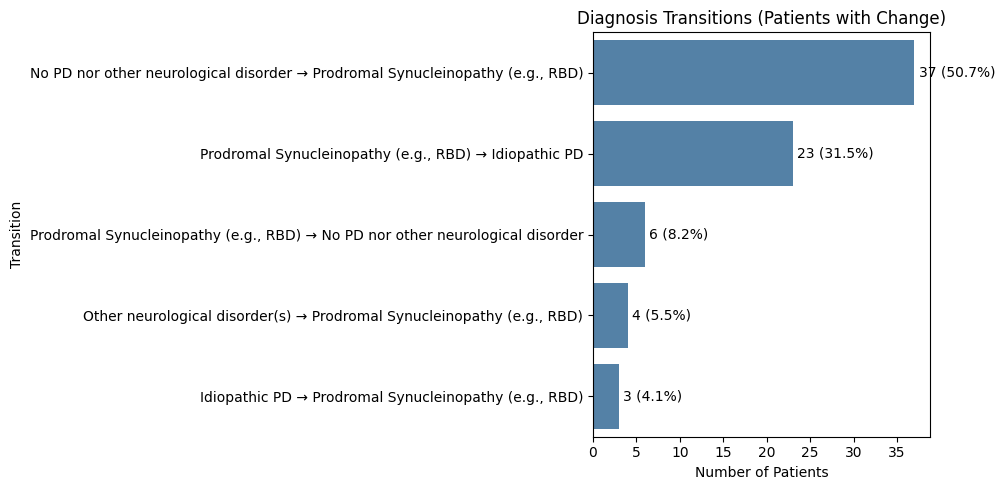

In [112]:
# Ensure visits are ordered in time
df_sorted = df.sort_values(["PATNO", "Study Date"])

transitions = []

for pat, group in df_sorted.groupby("PATNO"):
    diagnoses = group[column_name_for_transition].dropna().unique()

    if len(diagnoses) > 1:
        # Get ordered diagnoses per visit (not just unique)
        ordered_diag = (
            group[[column_name_for_transition, "Study Date"]]
            .dropna()
            .sort_values("Study Date")[column_name_for_transition]
            .tolist()
        )

        # Remove consecutive duplicates
        cleaned = [ordered_diag[0]]
        for d in ordered_diag[1:]:
            if d != cleaned[-1]:
                cleaned.append(d)

        # Create pairwise transitions
        for i in range(len(cleaned) - 1):
            transitions.append(f"{cleaned[i]} → {cleaned[i + 1]}")


transition_counts = pd.Series(transitions).value_counts()
print(len(transitions))
transition_counts = transition_counts.head(5)  # keep top 10 transitions

# Total number of transitions
total_transitions = transition_counts.sum()

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=transition_counts.values, y=transition_counts.index, color="steelblue"
)

plt.title("Diagnosis Transitions (Patients with Change)")
plt.xlabel("Number of Patients")
plt.ylabel("Transition")

# Annotate with count + percentage
for i, (count, label) in enumerate(
    zip(transition_counts.values, transition_counts.index)
):
    percentage = 100 * count / total_transitions
    ax.text(
        count + 0.5,  # position slightly to the right of bar
        i,
        f"{count} ({percentage:.1f}%)",
        va="center",
    )

plt.tight_layout()
plt.show()


# print("Transition counts:")
# print(transition_counts)

### Retention

/tmp/ipykernel_9452/4143225066.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[visite_date_column] = pd.to_datetime(df[visite_date_column], errors="coerce")


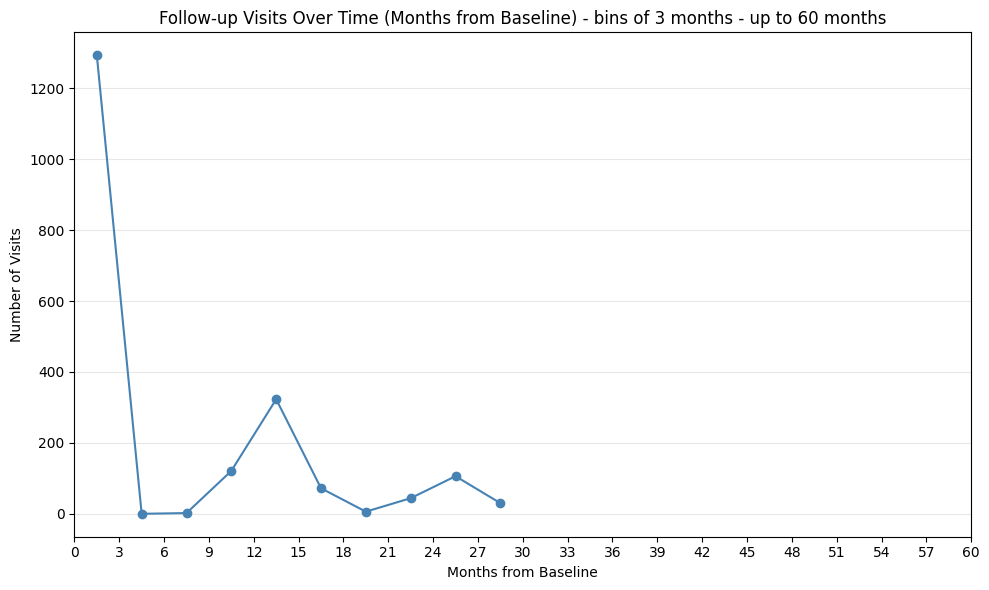

In [113]:
# Ensure datetime
visite_date_column = "visit_date"
df[visite_date_column] = pd.to_datetime(df[visite_date_column], errors="coerce")

# Keep unique patient-event pairs
df_unique = df.drop_duplicates(subset=["PATNO", "EVENT_ID"]).copy()

# 1️⃣ Baseline date per patient
baseline_dates = (
    df_unique[df_unique["EVENT_ID"] == "BL"].groupby("PATNO")[visite_date_column].min()
)
df_unique["baseline_date"] = df_unique["PATNO"].map(baseline_dates)

# 2️⃣ Time from baseline in months
df_unique["months_from_baseline"] = (
    df_unique["visit_date"] - df_unique["baseline_date"]
).dt.days / 30.44
df_unique = df_unique[df_unique["months_from_baseline"] >= 0].dropna(
    subset=["months_from_baseline"]
)

# 3️⃣ Plot as a curve
df_plot = df_unique[df_unique["months_from_baseline"] <= 60].copy()
bins = np.arange(0, df_plot["months_from_baseline"].max() + 1, 3)
counts, edges = np.histogram(df_plot["months_from_baseline"], bins=bins)

# Midpoints of bins for plotting
bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, counts, marker="o", linestyle="-", color="steelblue")
plt.title(
    "Follow-up Visits Over Time (Months from Baseline) - bins of 3 months - up to 60 months"
)
plt.xlabel("Months from Baseline")
plt.ylabel("Number of Visits")
plt.grid(axis="y", alpha=0.3)
plt.xticks(np.arange(0, 60 + 1, 3))

plt.tight_layout()
plt.show()


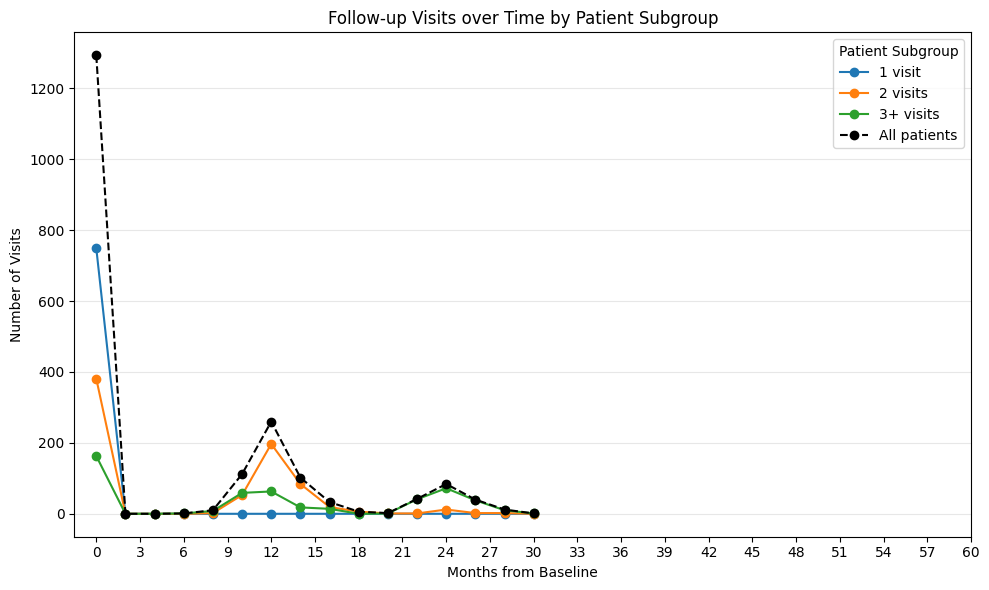

In [114]:
# Ensure datetime
df_unique = df.drop_duplicates(subset=["PATNO", "EVENT_ID"]).copy()
df_unique["visit_date"] = pd.to_datetime(df_unique["visit_date"], errors="coerce")

# Get baseline date per patient
baseline_dates = (
    df_unique[df_unique["EVENT_ID"] == "BL"].groupby("PATNO")["visit_date"].min()
)
df_unique["baseline_date"] = df_unique["PATNO"].map(baseline_dates)

# Compute months from baseline
df_unique["months_from_baseline"] = (
    df_unique["visit_date"] - df_unique["baseline_date"]
).dt.days / 30.44
df_unique = df_unique[df_unique["months_from_baseline"] >= 0]

# Compute total visits per patient
visits_per_patient = df_unique.groupby("PATNO")["EVENT_ID"].nunique()


# Assign subgroups based on total visits
def assign_visit_group(n):
    if n == 1:
        return "1 visit"
    elif n == 2:
        return "2 visits"
    else:
        return "3+ visits"
    # elif n == 3:
    #     return "3 visits"
    # elif n == 4:
    #     return "4 visits"

    # else:
    #     return "5+ visits"


df_unique["visit_group"] = (
    df_unique["PATNO"].map(visits_per_patient).map(assign_visit_group)
)
df_plot = df_unique[df_unique["months_from_baseline"] <= 60].copy()


# Plot
plt.figure(figsize=(10, 6))
bins = np.arange(0, df_plot["months_from_baseline"].max() + 1, 2)
for group_name, group_df in df_unique.groupby("visit_group"):
    counts, bin_edges = np.histogram(group_df["months_from_baseline"], bins=bins)
    # Convert counts to cumulative or normalized fraction if desired
    plt.plot(bin_edges[:-1], counts, marker="o", label=group_name)


# Plot full population
counts_all, _ = np.histogram(df_unique["months_from_baseline"], bins=bins)
plt.plot(
    bin_edges[:-1],
    counts_all,
    marker="o",
    color="black",
    linestyle="--",
    label="All patients",
)


plt.title("Follow-up Visits over Time by Patient Subgroup")
plt.xlabel("Months from Baseline")
plt.ylabel("Number of Visits")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Patient Subgroup")
plt.xticks(np.arange(0, 60 + 1, 3))

plt.tight_layout()
plt.show()


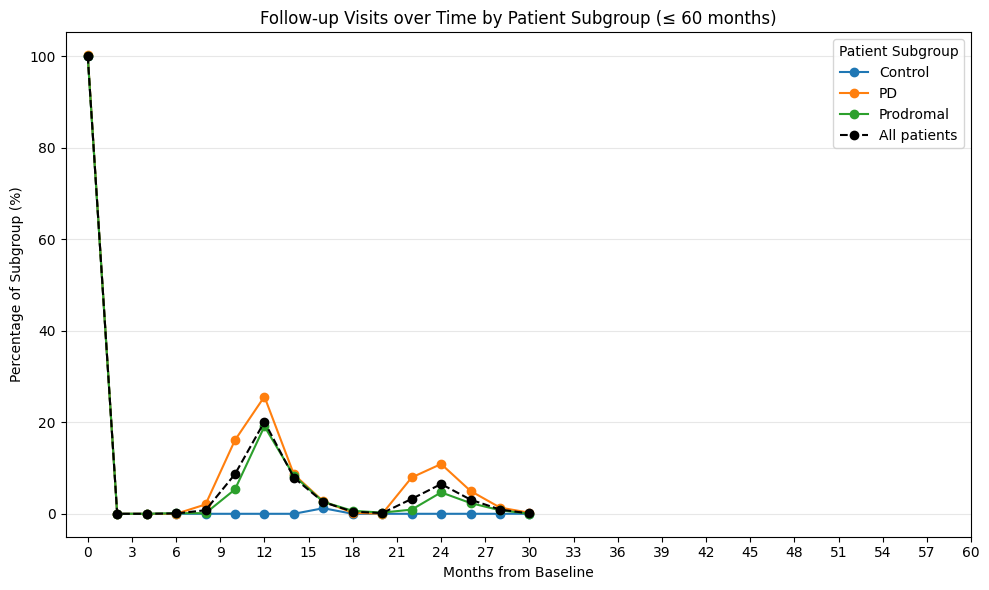

In [115]:
plt.figure(figsize=(10, 6))
bins = np.arange(0, df_plot["months_from_baseline"].max() + 1, 2)
# group_name = "visit_group"
group_name = "Research Group"
# Plot one curve per subgroup
for group_name, group_df in df_plot.groupby(group_name):
    # Get subgroup size (number of unique patients)
    n_patients = group_df["PATNO"].nunique()

    # Histogram counts
    counts, bin_edges = np.histogram(group_df["months_from_baseline"], bins=bins)

    # Convert to percentage relative to subgroup
    perc = counts / n_patients * 100

    plt.plot(bin_edges[:-1], perc, marker="o", label=group_name)

# Plot full population
total_patients = df_unique["PATNO"].nunique()
counts_all, _ = np.histogram(df_unique["months_from_baseline"], bins=bins)
perc_all = counts_all / total_patients * 100
plt.plot(
    bin_edges[:-1],
    perc_all,
    marker="o",
    color="black",
    linestyle="--",
    label="All patients",
)


plt.title("Follow-up Visits over Time by Patient Subgroup (≤ 60 months)")
plt.xlabel("Months from Baseline")
plt.ylabel("Percentage of Subgroup (%)")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Patient Subgroup")

# X-axis ticks every 3 months
plt.xticks(np.arange(0, 60 + 1, 3))

plt.tight_layout()
plt.show()


- Tous on une baseline
- si 2 visits, la deuxieme est surtout à +12 et parfois +24 ou +48
- si 3, 2 suivant surtout sur +12 +24
- si 4, les trois apres BL sont equitablement réparties sur +12 +24 +48
- si 5+, bonne répartition avec du +36

# Image analysis

### Basic info on rows level

In [116]:
df_image = df[df.columns.intersection(ida_df.columns)]
print("Image-related DataFrame shape:", df_image.shape)
print("Image-related DataFrame columns:", df_image.columns.tolist())

Image-related DataFrame shape: (23569, 31)
Image-related DataFrame columns: ['PATNO', 'EVENT_ID', 'Project', 'Sex', 'Weight', 'Research Group', 'Visit', 'Study Date', 'Archive Date', 'Age', 'GDSCALE Total Score', 'Modality', 'Description', 'Type', 'Imaging Protocol', 'Image ID', 'Structure', 'Laterality', 'Image Type', 'Registration', 'Tissue', 'Acquisition Plane', 'Slice Thickness', 'Matrix Z', 'Acquisition Type', 'Manufacturer', 'Mfg Model', 'Field Strength', 'Weighting', 'Description_clean', 'Advanced_Modality']


### histograms

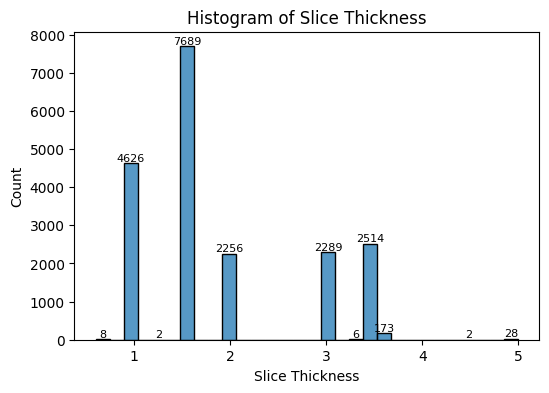

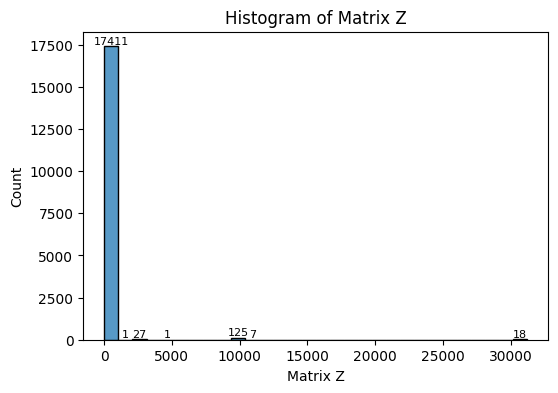

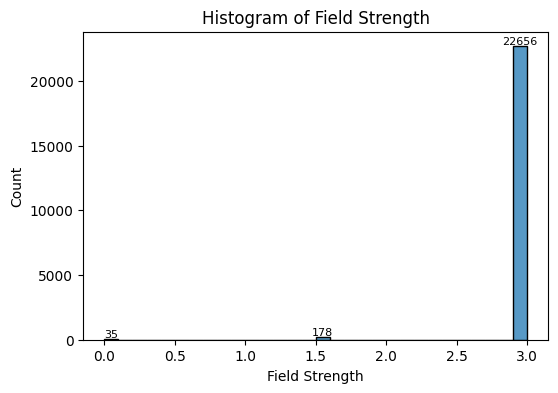

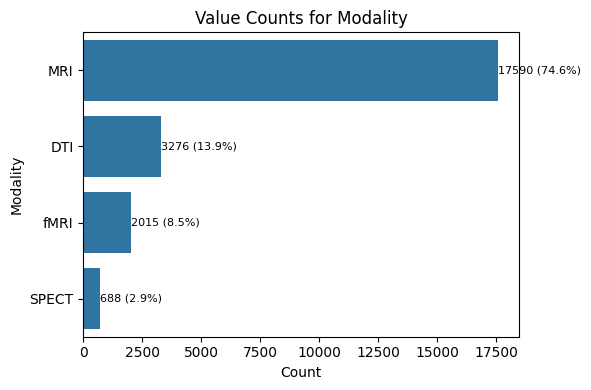

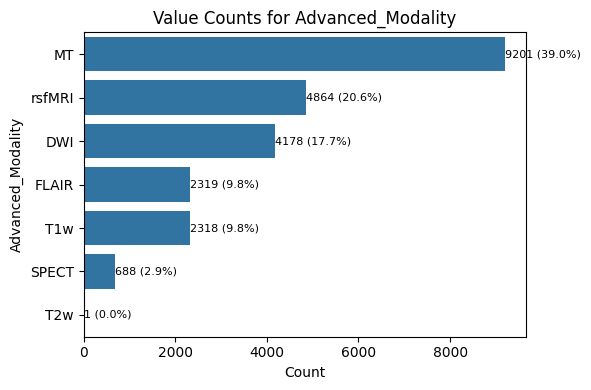

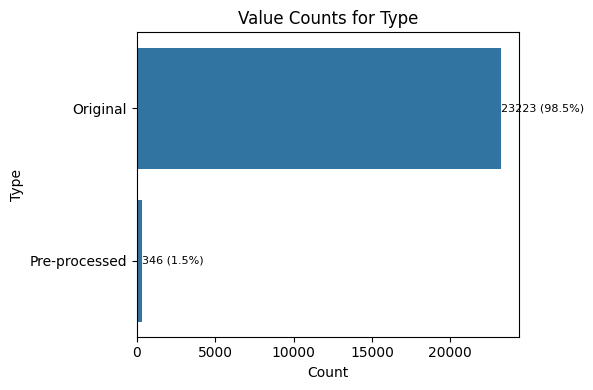

/tmp/ipykernel_9452/2768825900.py:88: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


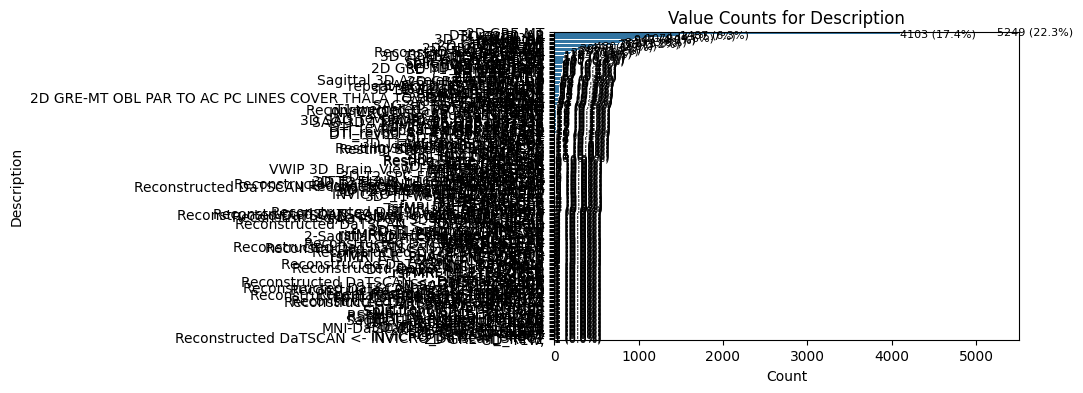

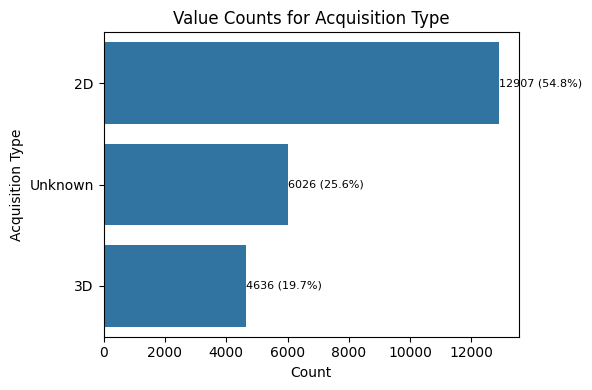

In [117]:
# Separate numeric and categorical columns
# numeric_cols = df_image.select_dtypes(include=np.number).columns
numeric_cols = ["Slice Thickness", "Matrix Z", "Field Strength"]
# numeric_cols = []

# -------------------------------
# Numeric Columns Histograms
# -------------------------------
for col in numeric_cols:
    plt.figure(figsize=(6, 4))

    # Plot histogram
    ax = sns.histplot(
        df_image[col].dropna(), bins=30, kde=False
    )  # disable KDE for counts clarity

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    # Annotate counts on top of each bin
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:  # only annotate non-empty bins
            ax.text(
                patch.get_x() + patch.get_width() / 2,  # center of bin
                height + 0.5,  # slightly above the bar
                int(height),  # show integer count
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.show()

# -------------------------------
# Categorical Columns Bar Plots
# -------------------------------
categorical_cols = [
    # "Visit",
    # "Sex",
    # "Research Group",
    "Modality",
    "Advanced_Modality",
    "Type",
    # "Structure",
    # "Laterality",
    # "Image Type",
    # "Registration",
    "Description",
    # "Tissue",
    # "Acquisition Plane",
    "Acquisition Type",
    # "Manufacturer",
    # "Mfg Model",
    # "Weighting",
]

categorical_cols = [col for col in categorical_cols if col in df_image.columns]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))

    df_image[col] = df_image[col].fillna("Unknown").astype(str)

    # Compute counts after cleaning
    counts = df_image[col].value_counts()
    total = counts.sum()
    order = counts.index.tolist()  # already strings

    ax = sns.countplot(y=col, data=df_image, order=order)

    for p, category in zip(ax.patches, order):
        count = counts.get(category, 0)
        percent = 100 * count / total

        ax.text(
            p.get_width() + 0.5,
            p.get_y() + p.get_height() / 2,
            f"{count} ({percent:.1f}%)",
            va="center",
            fontsize=8,
        )

    plt.title(f"Value Counts for {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### Image descriptions

In [118]:
# COunt the values of "Image Description"
print(df_image["Description"].value_counts(dropna=False).head(10))

Description
2D GRE-MT         5249
DTI_revB0_AP      4103
3D T2 FLAIR       1487
rsfMRI_RL         1333
3D T1-weighted    1079
rsfMRI_PA          947
rsfMRI_AP          945
2D GRE MT          840
rsfMRI_LR          781
2D GRE-NM_MT       755
Name: count, dtype: int64


### Simultaneous Multimodal Availability (Per Visit)

In [119]:
# Unique subject-visit-modality combinations
visit_modalities = (
    df.groupby(["PATNO", "EVENT_ID"])["Advanced_Modality"].unique().reset_index()
)

visit_modalities["n_modalities"] = visit_modalities["Advanced_Modality"].apply(len)
print(visit_modalities["n_modalities"].value_counts().to_frame().T)
print(visit_modalities["n_modalities"].describe().to_frame().T)


n_modalities    5    4    6   3  2
count         991  929  198  58  3
               count      mean      std  min  25%  50%  75%  max
n_modalities  2179.0  4.607159  0.69424  2.0  4.0  5.0  5.0  6.0


In [120]:
visit_modalities.head(2)

,PATNO,EVENT_ID,Advanced_Modality,n_modalities
0,100005,BL,"[T1w, FLAIR, MT, rsfMRI]",4
1,100005,V04,"[T1w, FLAIR, MT, rsfMRI, SPECT]",5


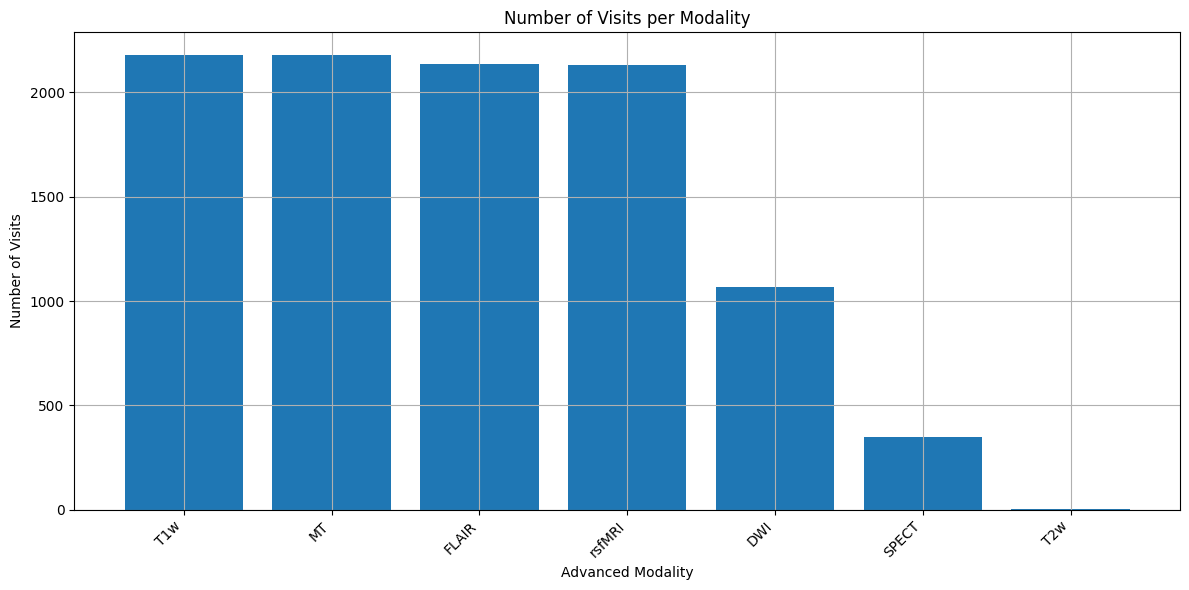

In [121]:
# Unique subject-visit-modality combinations
visit_modalities = (
    df.groupby(["PATNO", "EVENT_ID"])["Advanced_Modality"].unique().reset_index()
)

# Explode so each row is one modality per visit
exploded = visit_modalities.explode("Advanced_Modality")

# Count visits per modality
modality_counts = (
    exploded["Advanced_Modality"].value_counts().sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(modality_counts.index, modality_counts.values)

plt.title("Number of Visits per Modality")
plt.xlabel("Advanced Modality")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45, ha="right")
plt.grid(True)

plt.tight_layout()
plt.show()

In [122]:
# Create modality combination string
visit_modalities["modality_combo"] = visit_modalities["Advanced_Modality"].apply(
    lambda x: " | ".join(sorted(x))
)

# Count number of visits per combination
visit_counts = visit_modalities["modality_combo"].value_counts()

# Count number of unique patients per combination
patient_counts = (
    visit_modalities.groupby("modality_combo")["PATNO"]
    .nunique()
    .sort_values(ascending=False)
)

# Combine both in one table
summary = visit_counts.to_frame("n_visits").join(patient_counts.to_frame("n_patients"))

# print(summary)

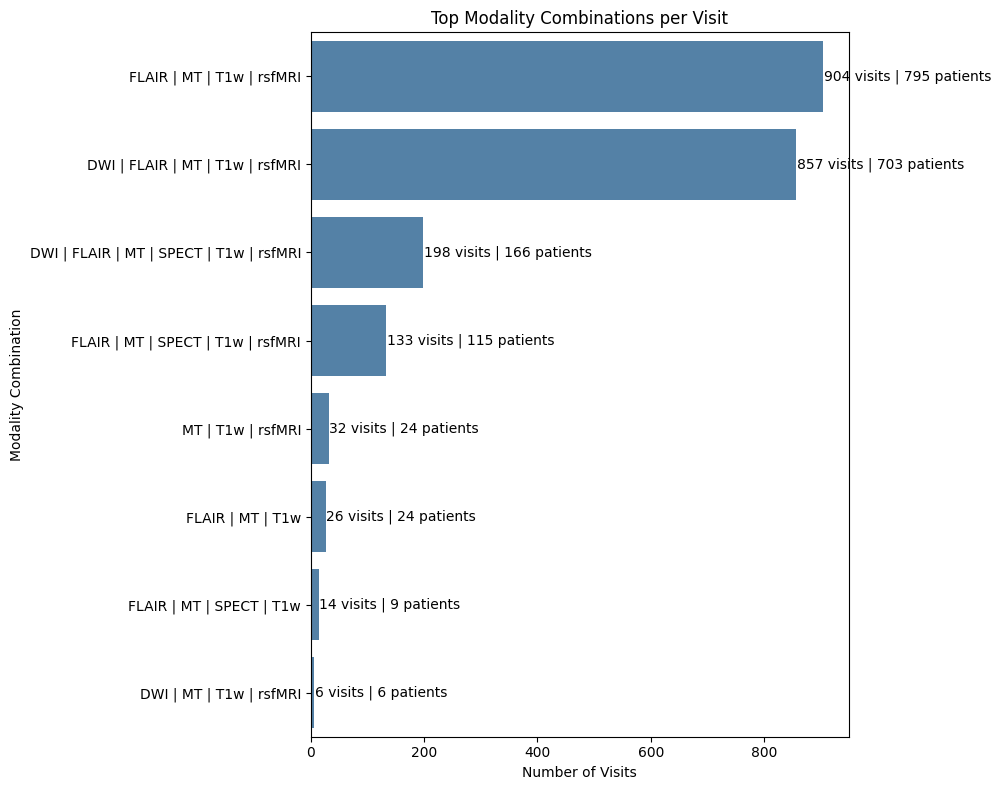

In [123]:
# Optional: keep only top 15 combinations for readability
top_n = 8
summary_plot = summary.sort_values("n_visits", ascending=False).head(top_n)

plt.figure(figsize=(10, 8))

ax = sns.barplot(x=summary_plot["n_visits"], y=summary_plot.index, color="steelblue")

plt.title("Top Modality Combinations per Visit")
plt.xlabel("Number of Visits")
plt.ylabel("Modality Combination")

# Annotate counts
for i, (visits, patients) in enumerate(
    zip(summary_plot["n_visits"], summary_plot["n_patients"])
):
    ax.text(visits + 1, i, f"{visits} visits | {patients} patients", va="center")

plt.tight_layout()
plt.show()

In [124]:
# Pivot to binary presence matrix
visit_modality_matrix = (
    df.assign(present=1)
    .drop_duplicates(["PATNO", "EVENT_ID", "Advanced_Modality"])
    .pivot_table(
        index=["PATNO", "EVENT_ID"],
        columns="Advanced_Modality",
        values="present",
        fill_value=0,
    )
)
co_occurrence = visit_modality_matrix.T @ visit_modality_matrix
print(co_occurrence)

Advanced_Modality     DWI   FLAIR      MT  SPECT     T1w  T2w  rsfMRI
Advanced_Modality                                                    
DWI                1066.0  1059.0  1066.0  199.0  1066.0  0.0  1062.0
FLAIR              1059.0  2136.0  2136.0  345.0  2136.0  0.0  2092.0
MT                 1066.0  2136.0  2179.0  346.0  2179.0  1.0  2132.0
SPECT               199.0   345.0   346.0  346.0   346.0  0.0   332.0
T1w                1066.0  2136.0  2179.0  346.0  2179.0  1.0  2132.0
T2w                   0.0     0.0     1.0    0.0     1.0  1.0     1.0
rsfMRI             1062.0  2092.0  2132.0  332.0  2132.0  1.0  2132.0


In [125]:
df.head(2)

,SITE,PATNO,COHORT,subgroup,enroll_phase,enroll_source,analytic_subgroup,HIQ_RBD,study_status,NSD_Status,...,Acquisition Plane,Slice Thickness,Matrix Z,Acquisition Type,Manufacturer,Mfg Model,Field Strength,Weighting,Description_clean,Advanced_Modality
0,33.0,100005,1.0,Sporadic PD,2.0,NaN,NaN,NaN,Active,1.0,...,SAGITTAL,1.0,192.0,3D,SIEMENS,Prisma_fit,3.0,PD,3D T1 _WEIGHTED,T1w
1,33.0,100005,1.0,Sporadic PD,2.0,NaN,NaN,NaN,Active,1.0,...,SAGITTAL,1.0,192.0,3D,SIEMENS,Prisma_fit,3.0,T2,3D T2 FLAIR,FLAIR


# Image IDs
Should be useful to download the data

In [126]:
image_ids = (
    df["Image ID"]
    .dropna()  # remove NaNs
    .apply(
        lambda x: str(int(x)) if isinstance(x, float) else str(x).strip()
    )  # float → int → str, else str
    .unique()
    .tolist()
)

print(f"Unique Image IDs: {len(image_ids)}")
print(",".join(image_ids))


Unique Image IDs: 23569
1526357,1526361,1526362,1526363,1526364,1526365,1526366,1526359,1526360,1526358,1548621,1548624,1548625,1548622,1548623,1548430,1548448,1526373,1526377,1526378,1526379,1526380,1526381,1526382,1526375,1526376,1526374,1530144,1530147,1530148,1530145,1530146,1537893,1537900,1692865,1692868,1692869,1692866,1692867,10256354,10380466,1692870,1692874,1692875,1692876,1525725,1525728,1525729,1525730,1525731,1525732,1525733,1525726,1525727,1537552,1537555,1537556,1537553,1537554,1548431,1548449,1692878,1692881,1692882,1692879,1692880,10293704,10380467,1692883,1692886,1692889,1692890,1525538,1525539,1525540,1525541,1525542,1525543,1525544,1525545,1525546,1561306,1561309,1561310,1561311,1561312,1561313,1561314,1561307,1561308,1573136,1573146,1660784,1660785,1660786,1660787,1660788,1660789,1660790,1660791,1660792,1670052,1671552,1497577,1497578,1497581,1497582,1497583,1497584,1497585,1497586,1497587,1497579,1497580,1700998,1701001,1701002,1701003,1701004,1701005,1701006,1701